In [2]:
from fastai.vision.all import *
from fastai.callback.fp16 import *

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from collections import Counter
from torch.utils.data import WeightedRandomSampler

import numpy as np
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
fname = '/content/drive/MyDrive/endocellgraph'

In [9]:
dblock = DataBlock(blocks = (ImageBlock, CategoryBlock),
                   get_items = get_image_files,
                   get_y = parent_label,
                   splitter = RandomSplitter(seed=42),
                   item_tfms = Resize(384),
                   batch_tfms = aug_transforms(mult=1.5, flip_vert=True, max_rotate=180, max_zoom=1.1, max_lighting=0.3))

In [11]:
dls = dblock.dataloaders(fname, bs=64)

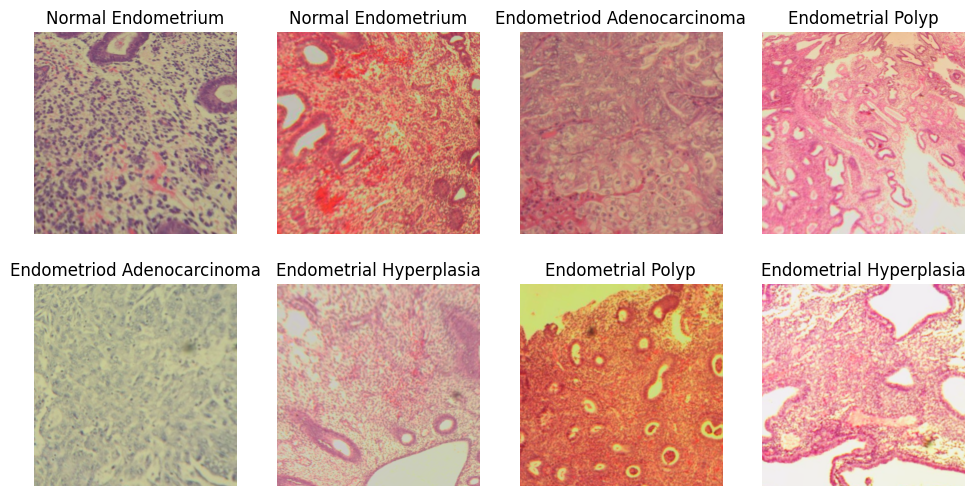

In [13]:
dls.show_batch(max_n = 8)

In [14]:
metrics = [accuracy,
           Precision(average='macro'),
           Recall(average='macro'),
           F1Score(average='macro')]

In [15]:
learn = vision_learner(dls, resnet50, metrics=metrics, loss_func = CrossEntropyLossFlat(), opt_func = Adam).to_fp16()

<div></div>

SuggestedLRs(valley=0.0014454397605732083)

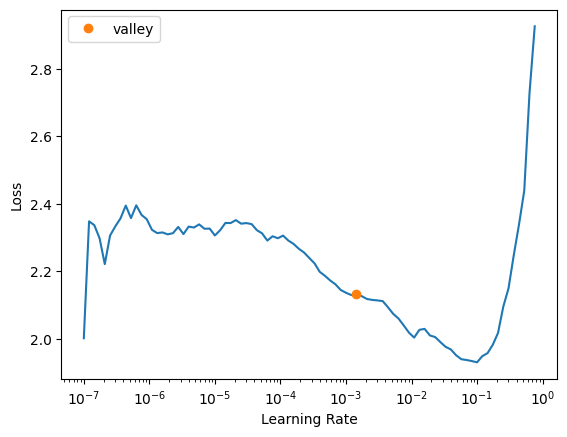

In [16]:
learn.lr_find()

In [19]:
learn.fit_one_cycle(15, lr_max = slice(1e-3, 1e-2))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.663276,1.070863,0.637462,0.647755,0.632658,0.635996,00:46
1,1.351814,0.892154,0.678248,0.682142,0.659340,0.663497,00:47
2,1.152186,0.741271,0.702417,0.717874,0.674051,0.684233,00:43
3,1.043768,0.955448,0.643505,0.667724,0.617254,0.627389,00:43
4,0.987986,0.739413,0.682779,0.721758,0.631983,0.657831,00:43
5,0.920041,0.639745,0.737160,0.737019,0.700927,0.708952,00:41
6,0.854137,0.659618,0.719033,0.733906,0.732740,0.720898,00:43
7,0.794517,0.609980,0.752266,0.750395,0.771353,0.754186,00:41
8,0.738852,0.558371,0.743202,0.744582,0.747313,0.741224,00:42
9,0.682447,0.523328,0.780967,0.799348,0.751770,0.769435,00:42


In [20]:
preds, targs = learn.tta()

y_pred = preds.argmax(dim=1)

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    confusion_matrix
)

import numpy as np

# Sensitivity
sensitivity = recall_score(
    targs.cpu(),
    y_pred.cpu(),
    average='macro'
)

# ROC-AUC
roc_auc = roc_auc_score(
    targs.cpu(),
    preds.cpu(),
    multi_class='ovr',
    average='macro'
)

# Specificity
cm = confusion_matrix(
    targs.cpu(),
    y_pred.cpu()
)

specificities = []

for i in range(len(cm)):

    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    specificities.append(
        TN/(TN+FP)
    )

specificity = np.mean(specificities)

print(f"Sensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time


<div></div>

Sensitivity : 0.7932
Specificity : 0.9277
ROC-AUC     : 0.9572
